In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## EDA

In [34]:
path = "/home/sjoon/projects/brain_connectivity_classifier/data/raw/"

try:
    # Load intelligence data
    intelligence_rest_df = pd.read_csv(path + "participants_PIOP2.tsv", sep='\t')
    intelligence_task_df = pd.read_csv(path + "participants_PIOP1.tsv", sep='\t')

    # Load connectivity data
    connectivity_rest_df = pd.read_csv(path + "PIOP2_restingstate.csv")
    connectivity_task_df = pd.read_csv(path + "PIOP1_gstroop.csv")
    print("Data loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading data: {e}")



Data loaded successfully.


In [35]:
# filter subjects from intelligence data present in connectivity data

# Remove '_P2' suffix from subject IDs in connectivity_rest_df
connectivity_rest_df['subject'] = connectivity_rest_df['subject'].str.replace('_P2', '', regex=False)

# Get unique subject IDs from connectivity data
rest_subjects = connectivity_rest_df.subject.unique()
task_subjects = connectivity_task_df.subject.unique()

# Filter intelligence data to include only subjects present in connectivity data
intelligence_rest_df = intelligence_rest_df[intelligence_rest_df.participant_id.isin(rest_subjects)]
intelligence_task_df = intelligence_task_df[intelligence_task_df.participant_id.isin(task_subjects)]

# Print the number of unique participants after filtering
print(f'Number of unique participants in filtered intelligence_rest_df: {intelligence_rest_df.participant_id.nunique()}')
print(f'Number of unique participants in filtered intelligence_task_df: {intelligence_task_df.participant_id.nunique()}')

Number of unique participants in filtered intelligence_rest_df: 224
Number of unique participants in filtered intelligence_task_df: 200


In [90]:
intelligence_rest_df = intelligence_rest_df.reset_index(drop=True)
intelligence_rest_df.head()

,participant_id,age,sex,BMI,handedness,education_category,raven_score,NEO_N,NEO_E,NEO_O,NEO_A,NEO_C
0,sub-0001,25.50,M,21.0,right,academic,33.0,23,40,52,47,32
1,sub-0002,23.25,F,22.0,right,academic,19.0,22,47,34,53,46
2,sub-0003,25.00,F,23.0,right,applied,29.0,26,42,37,48,48
3,sub-0004,20.00,F,18.0,right,academic,24.0,32,42,36,48,52
4,sub-0005,24.75,M,27.0,right,academic,24.0,32,51,41,51,53


NEO_N: Neuroticism (tendency toward negative emotions, emotional instability).

NEO_E: Extraversion (sociability, energy, positive affect).

NEO_O: Openness to Experience (curiosity, preference for novelty and variety).

NEO_A: Agreeableness (cooperativeness, empathy, prosocial orientation).

NEO_C: Conscientiousness (organization, self-discipline, goal-directed behavior).

### Raven Score 

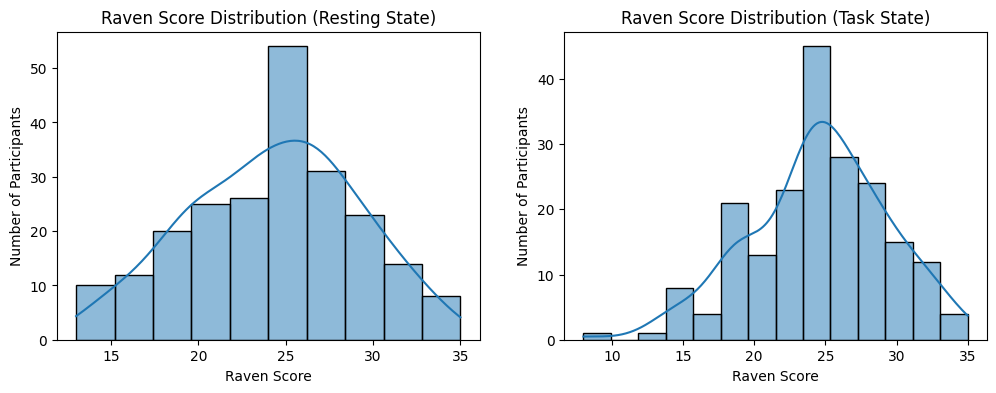

In [91]:
# Raven score distribution in resting state and task state
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plotting raven score distribution in resting state
sns.histplot(x='raven_score', data=intelligence_rest_df, ax=axes[0], kde=True)
axes[0].set_title('Raven Score Distribution (Resting State)')
axes[0].set_xlabel('Raven Score')
axes[0].set_ylabel('Number of Participants')

# Plotting raven score distribution in task state
sns.histplot(x='raven_score', data=intelligence_task_df, ax=axes[1], kde=True)
axes[1].set_title('Raven Score Distribution (Task State)')
axes[1].set_xlabel('Raven Score')
axes[1].set_ylabel('Number of Participants')

plt.show()


In [92]:
import pandas as pd
import numpy as np

print(" RAVEN SCORE DESCRIPTIVE STATISTICS")
# Side-by-side comparison table
stats_rest = intelligence_rest_df.raven_score.describe()
stats_task = intelligence_task_df.raven_score.describe()

comparison_df = pd.DataFrame({
    'Resting State': stats_rest,
    'Task State': stats_task
}).round(2)

print(comparison_df)

 RAVEN SCORE DESCRIPTIVE STATISTICS
       Resting State  Task State
count         223.00      199.00
mean           24.27       24.53
std             4.86        4.89
min            13.00        8.00
25%            21.00       22.00
50%            24.00       25.00
75%            28.00       28.00
max            35.00       35.00


### Sex

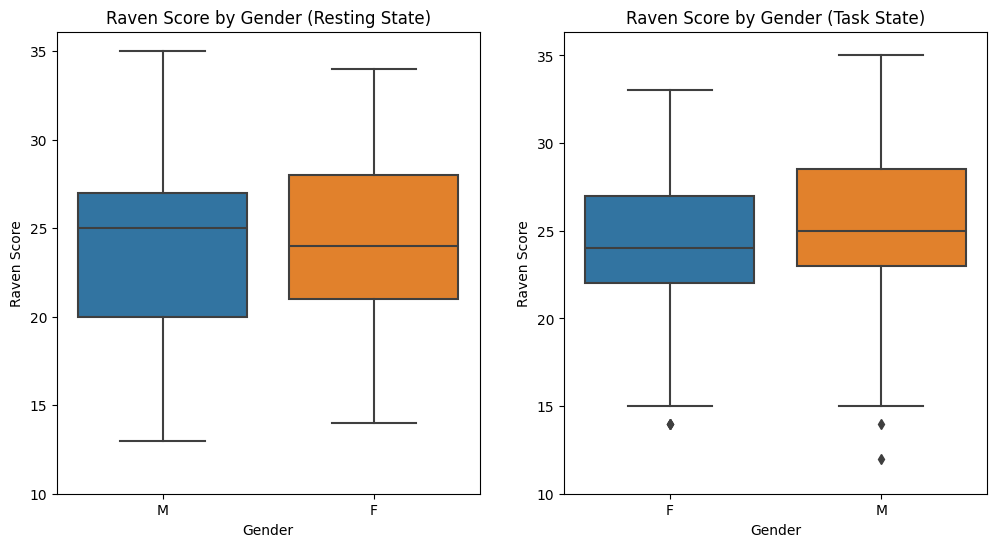

In [93]:
# Ploting raven score by gender in resting state and task state using subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plotting raven score by gender in resting state
sns.boxplot(x='sex', y='raven_score', data=intelligence_rest_df, ax=axes[0])
axes[0].set_title('Raven Score by Gender (Resting State)')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Raven Score')
axes[0].set_ylim(10,)

# Plotting raven score by gender in task state
sns.boxplot(x='sex', y='raven_score', data=intelligence_task_df, ax=axes[1])
axes[1].set_title('Raven Score by Gender (Task State)')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Raven Score')
axes[1].set_ylim(10, )

plt.show()

In [94]:
# Print Raven score summary by gender for resting state
print("Resting State - Raven Score by Gender:")
print(intelligence_rest_df.groupby('sex')['raven_score'].describe())
print("\n")

# Print Raven score summary by gender for task state  
print("Task State - Raven Score by Gender:")
print(intelligence_task_df.groupby('sex')['raven_score'].describe())


Resting State - Raven Score by Gender:
     count       mean       std   min   25%   50%   75%   max
sex                                                          
F    128.0  24.296875  4.653945  14.0  21.0  24.0  28.0  34.0
M     95.0  24.231579  5.153913  13.0  20.0  25.0  27.0  35.0


Task State - Raven Score by Gender:
     count       mean       std   min   25%   50%   75%   max
sex                                                          
F    109.0  24.091743  4.689510   8.0  22.0  24.0  27.0  33.0
M     83.0  25.240964  5.049971  12.0  23.0  25.0  28.5  35.0


### Handedness

In [95]:
# handedness distribution in resting state and task state

print(f"Handedness distribution in resting state: {intelligence_rest_df['handedness'].value_counts()} \n")
print(f"Handedness distribution in task state: {intelligence_task_df['handedness'].value_counts()}")

Handedness distribution in resting state: handedness
right           199
left             22
ambidextrous      1
Name: count, dtype: int64 

Handedness distribution in task state: handedness
right           167
left             22
ambidextrous      4
Name: count, dtype: int64


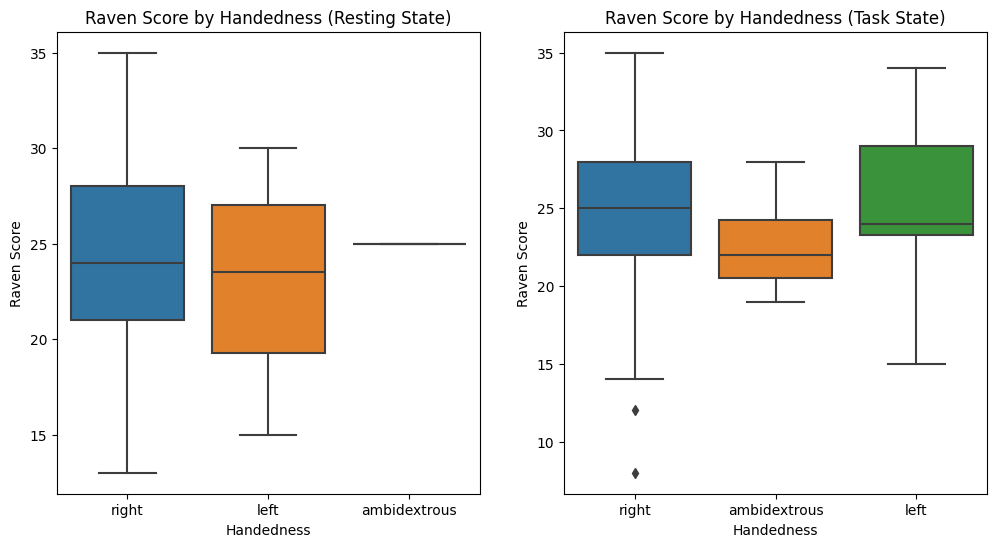

In [96]:
# Ploting raven score by handedness in resting state and task state using subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plotting raven score by handedness in resting state
sns.boxplot(x='handedness', y='raven_score', data=intelligence_rest_df, ax=axes[0])
axes[0].set_title('Raven Score by Handedness (Resting State)')
axes[0].set_xlabel('Handedness')
axes[0].set_ylabel('Raven Score')

# Plotting raven score by handedness in task state
sns.boxplot(x='handedness', y='raven_score', data=intelligence_task_df, ax=axes[1])
axes[1].set_title('Raven Score by Handedness (Task State)')
axes[1].set_xlabel('Handedness')
axes[1].set_ylabel('Raven Score')

plt.show()

### Age

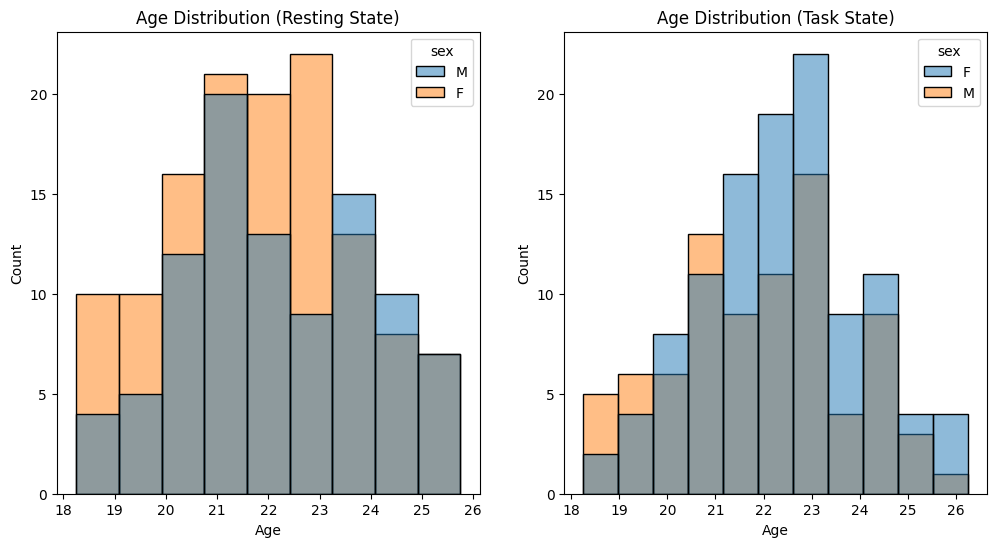

In [97]:
# Plotting age distribution in resting state and task state using subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plotting age distribution in resting state
sns.histplot(data=intelligence_rest_df, x='age', hue='sex', ax=axes[0])
axes[0].set_title('Age Distribution (Resting State)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Plotting age distribution in task state
sns.histplot(data=intelligence_task_df, x='age', hue='sex', ax=axes[1])
axes[1].set_title('Age Distribution (Task State)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

plt.show()

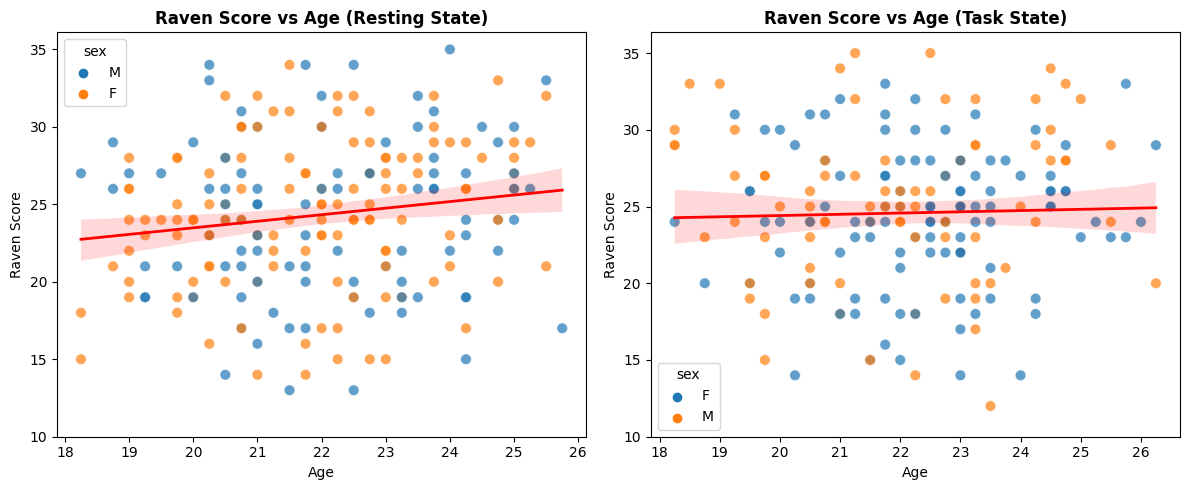

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Resting state: Age vs Raven Score scatter
sns.scatterplot(x='age', y='raven_score', data=intelligence_rest_df, ax=axes[0], alpha=0.7, s=60, hue='sex')
sns.regplot(x='age', y='raven_score', data=intelligence_rest_df, ax=axes[0], scatter=False, color='red', line_kws={'linewidth': 2})
axes[0].set_title('Raven Score vs Age (Resting State)', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Raven Score')
axes[0].set_ylim(10,)

# Task state: Age vs Raven Score scatter
sns.scatterplot(x='age', y='raven_score', data=intelligence_task_df, ax=axes[1], alpha=0.7, s=60, hue='sex')
sns.regplot(x='age', y='raven_score', data=intelligence_task_df, ax=axes[1], scatter=False, color='red', line_kws={'linewidth': 2})
axes[1].set_title('Raven Score vs Age (Task State)', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Raven Score')
axes[1].set_ylim(10,)

plt.tight_layout()
plt.show()

### BMI

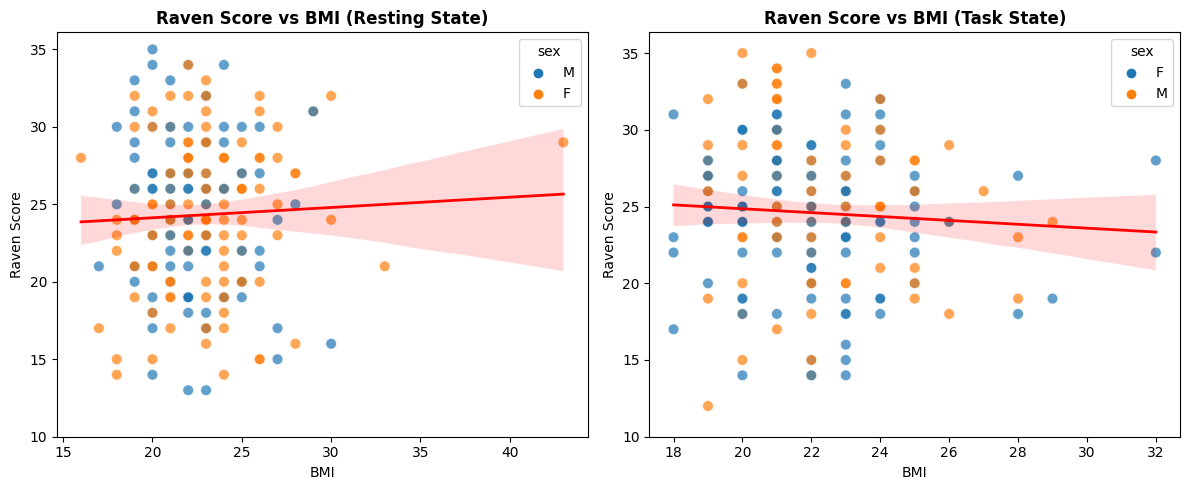

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Resting state: BMI vs Raven Score scatter
sns.scatterplot(x='BMI', y='raven_score', data=intelligence_rest_df, ax=axes[0], alpha=0.7, s=60, hue='sex')
sns.regplot(x='BMI', y='raven_score', data=intelligence_rest_df, ax=axes[0], scatter=False, color='red', line_kws={'linewidth': 2})
axes[0].set_title('Raven Score vs BMI (Resting State)', fontweight='bold')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Raven Score')
axes[0].set_ylim(10,)

# Task state: BMI vs Raven Score scatter
sns.scatterplot(x='BMI', y='raven_score', data=intelligence_task_df, ax=axes[1], alpha=0.7, s=60, hue='sex')
sns.regplot(x='BMI', y='raven_score', data=intelligence_task_df, ax=axes[1], scatter=False, color='red', line_kws={'linewidth': 2})
axes[1].set_title('Raven Score vs BMI (Task State)', fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Raven Score')
axes[1].set_ylim(10,)

plt.tight_layout()
plt.show()

### Education Category 

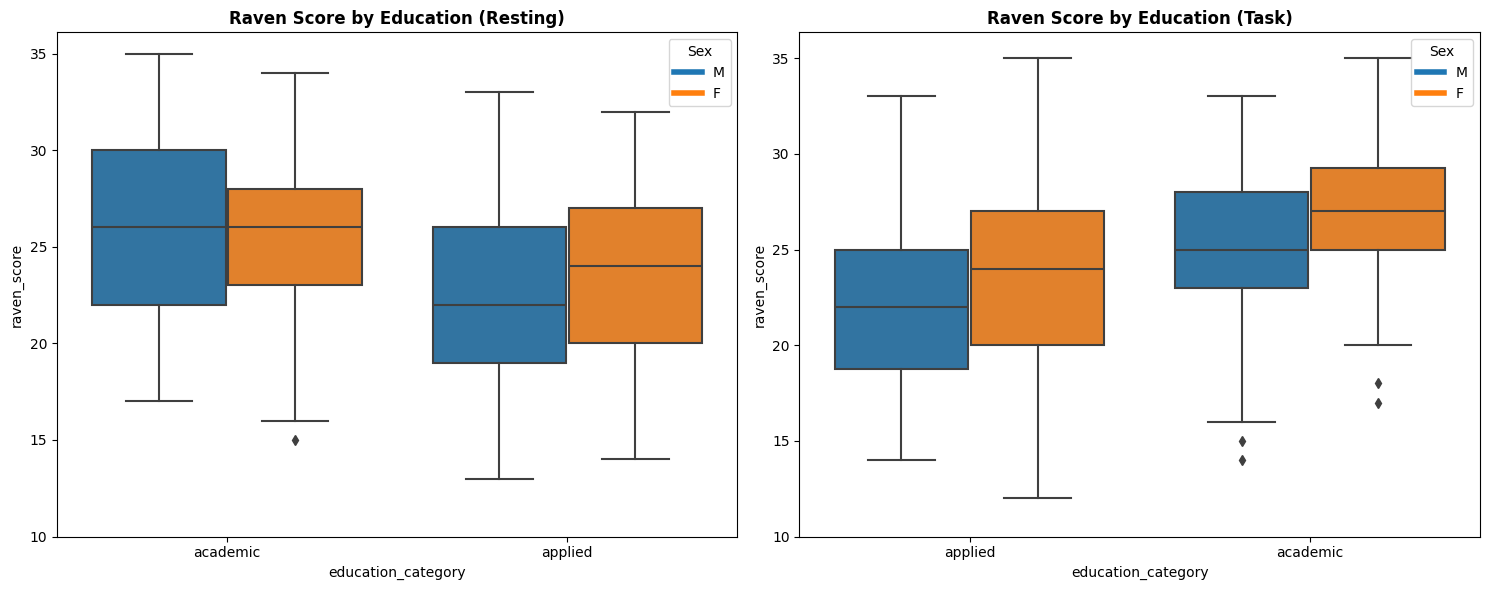

In [100]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot resting state
sns.boxplot(x='education_category', y='raven_score', hue='sex', 
            data=intelligence_rest_df, ax=axes[0], 
            palette=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Raven Score by Education (Resting)', fontweight='bold')
axes[0].set_ylim(10, )

# Plot task state  
sns.boxplot(x='education_category', y='raven_score', hue='sex', 
            data=intelligence_task_df, ax=axes[1], 
            palette=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Raven Score by Education (Task)', fontweight='bold')
axes[1].set_ylim(10, )

# Create IDENTICAL custom legends for both plots
legend_elements = [
    Line2D([0], [0], color='#1f77b4', lw=4, label='M'),
    Line2D([0], [0], color='#ff7f0e', lw=4, label='F')
]

# Apply SAME legend to both subplots
axes[0].legend(handles=legend_elements, title='Sex', loc='upper right')
axes[1].legend(handles=legend_elements, title='Sex', loc='upper right')

plt.tight_layout()
plt.show()


In [101]:
print("RAVEN SCORES BY EDUCATION CATEGORY & SEX")
print("=" * 70)

# Resting State
print("\nRESTING STATE")
rest_summary = intelligence_rest_df.groupby(['education_category', 'sex'])['raven_score'].agg(['count', 'mean', 'std', 'min', 'max']).round(1)
print(rest_summary)

# Task State  
print("\nTASK STATE")
task_summary = intelligence_task_df.groupby(['education_category', 'sex'])['raven_score'].agg(['count', 'mean', 'std', 'min', 'max']).round(1)
print(task_summary)

RAVEN SCORES BY EDUCATION CATEGORY & SEX

RESTING STATE
                        count  mean  std   min   max
education_category sex                              
academic           F       56  25.4  4.4  15.0  34.0
                   M       47  26.0  4.7  17.0  35.0
applied            F       72  23.4  4.7  14.0  32.0
                   M       48  22.5  5.0  13.0  33.0

TASK STATE
                        count  mean  std   min   max
education_category sex                              
academic           F       73  25.3  4.0  14.0  33.0
                   M       36  27.2  4.3  17.0  35.0
applied            F       36  21.6  5.0   8.0  33.0
                   M       47  23.7  5.1  12.0  35.0


## Behavior analysis

In [102]:
# =============================================================================
# PATH VERIFICATION
# =============================================================================


BASE_PATH = Path('/home/sjoon/projects/brain_connectivity_classifier/data')
RESULTS_DIR = BASE_PATH / 'results'

# Template for repetitive paths
def res_p(sub, task): return RESULTS_DIR / sub / task
l_sub, r_sub = 'hemisphere_analysis/left_hemisphere', 'hemisphere_analysis/right_hemisphere'
ovr, t_ovr = 'one_vs_rest', 'task_testing_one_vs_rest'

PATHS = {
    'left_cv': res_p(l_sub, ovr) / 'cv_summary.json',
    'left_task': res_p(l_sub, t_ovr) / 'task_testing_summary.json',
    'left_pred': res_p(l_sub, t_ovr) / 'task_predictions.npy',
    'left_true': res_p(l_sub, t_ovr) / 'task_true_labels.npy',
    
    'right_cv': res_p(r_sub, ovr) / 'cv_summary.json',
    'right_task': res_p(r_sub, t_ovr) / 'task_testing_summary.json',
    'right_pred': res_p(r_sub, t_ovr) / 'task_predictions.npy',
    'right_true': res_p(r_sub, t_ovr) / 'task_true_labels.npy',
    
    'full_regions': BASE_PATH / 'FULL_region_info.csv',
    'lh_regions': BASE_PATH / 'LH_region_info.csv',
    'rh_regions': BASE_PATH / 'RH_region_info.csv',
    'coordinates': BASE_PATH / 'network_files' / 'Schaefer2018_200Parcels_Tian_32Parcels.csv'
}

# Condensed Verification
print("Path Verification:")
missing_paths = [n for n, p in PATHS.items() if not (print(f"  {'✓' if p.exists() else '✗'} {n}{'' if p.exists() else ' - MISSING'}") or p.exists())]

if missing_paths: print(f"\n⚠ Warning: {len(missing_paths)} path(s) missing")
else: print("\n✓ All paths verified successfully")

Path Verification:
  ✓ left_cv
  ✓ left_task
  ✓ left_pred
  ✓ left_true
  ✓ right_cv
  ✓ right_task
  ✓ right_pred
  ✓ right_true
  ✓ full_regions
  ✓ lh_regions
  ✓ rh_regions
  ✓ coordinates

✓ All paths verified successfully


In [103]:
# =============================================================================
# DATA LOADING
# =============================================================================
print("Loading data...\n")

# 1. Load region metadata
full_region_info = pd.read_csv(PATHS['full_regions'])
lh_region_info = pd.read_csv(PATHS['lh_regions'])
rh_region_info = pd.read_csv(PATHS['rh_regions'])
coords_df = pd.read_csv(PATHS['coordinates'])

print(f"✓ Metadata loaded: Full ({len(full_region_info)}), Left ({len(lh_region_info)}), Right ({len(rh_region_info)})")

# 2. Load performance summaries
def load_summary(path):
    with open(path, 'r') as f: return json.load(f)

s_keys = ['left_cv', 'left_task', 'right_cv', 'right_task']
left_cv, left_task, right_cv, right_task = [load_summary(PATHS[k]) for k in s_keys]

# 3. Load predictions and labels
p_keys = [('left_pred', 'left_true'), ('right_pred', 'right_true')]
preds_data = [ (np.load(PATHS[p], allow_pickle=True), np.load(PATHS[t], allow_pickle=True)) for p, t in p_keys]

(left_preds, left_true), (right_preds, right_true) = preds_data



print(f"\n✓ Summaries and Predictions loaded:")
print(f" Left: {len(left_preds):,} | Right: {len(right_preds):,}")
print(f"\n DATA LOADING COMPLETE")

Loading data...

✓ Metadata loaded: Full (232), Left (116), Right (116)

✓ Summaries and Predictions loaded:
 Left: 23,200 | Right: 23,200

 DATA LOADING COMPLETE


In [104]:
# =============================================================================
# PER-SUBJECT ACCURACY & MISCLASSIFICATION RATE
# =============================================================================

# Per-subject accuracy: fraction of correctly classified regions per subject
n_regions_lh = len(lh_region_info)  # 116
n_regions_rh = len(rh_region_info)  # 116
print(f"Regions loaded: Left ({n_regions_lh}), Right ({n_regions_rh})")

# 200 subjects
n_subjects_lh = len(left_preds) // n_regions_lh   # 200
n_subjects_rh = len(right_preds) // n_regions_rh  # 200
print(f'Number of subjects: Left{n_subjects_lh}, Right {n_subjects_rh}')

# Reshape
left_preds_2d  = left_preds.reshape(n_subjects_lh, n_regions_lh)
left_true_2d   = left_true.reshape(n_subjects_lh, n_regions_lh)
print(f'left_preds_2d.shape, left_true_2d.shape: {left_preds_2d.shape}, {left_true_2d.shape}')


right_preds_2d = right_preds.reshape(n_subjects_rh, n_regions_rh)
right_true_2d  = right_true.reshape(n_subjects_rh, n_regions_rh)
print(f'right_preds_2d.shape, right_true_2d.shape: {right_preds_2d.shape}, {right_true_2d.shape}')

# Per-subject accuracy: fraction of correctly classified regions per subject
left_per_subj_acc  = (left_preds_2d == left_true_2d).mean(axis=1)   # shape (200,)
right_per_subj_acc = (right_preds_2d == right_true_2d).mean(axis=1) # shape (200,)

# Per-subject misclassification rate (just 1 - accuracy)
left_per_subj_mis  = 1.0 - left_per_subj_acc
right_per_subj_mis = 1.0 - right_per_subj_acc

# --- Summary DataFrame (easy to inspect / plot) ---
per_subject_df = pd.DataFrame({
    'subject_idx':          range(n_subjects_lh),
    'left_accuracy':        left_per_subj_acc,
    'left_misclass_rate':   left_per_subj_mis,
    'right_accuracy':       right_per_subj_acc,
    'right_misclass_rate':  right_per_subj_mis,
    'mean_accuracy':        (left_per_subj_acc + right_per_subj_acc) / 2,
    'mean_misclass_rate':   (left_per_subj_mis + right_per_subj_mis) / 2
})

display(per_subject_df.head())

Regions loaded: Left (116), Right (116)
Number of subjects: Left200, Right 200
left_preds_2d.shape, left_true_2d.shape: (200, 116), (200, 116)
right_preds_2d.shape, right_true_2d.shape: (200, 116), (200, 116)


,subject_idx,left_accuracy,left_misclass_rate,right_accuracy,right_misclass_rate,mean_accuracy,mean_misclass_rate
0,0,0.931034,0.068966,0.922414,0.077586,0.926724,0.073276
1,1,0.801724,0.198276,0.818966,0.181034,0.810345,0.189655
2,2,0.931034,0.068966,0.913793,0.086207,0.922414,0.077586
3,3,0.922414,0.077586,0.827586,0.172414,0.875000,0.125000
4,4,0.887931,0.112069,0.844828,0.155172,0.866379,0.133621


In [105]:
temp_data = pd.DataFrame(index=intelligence_task_df.index, 
                         columns=['raven_score', 'mean_accuracy', 'mean_misclass_rate'])

temp_data['raven_score'] = intelligence_task_df['raven_score']
temp_data['mean_accuracy'] = per_subject_df['mean_accuracy']
temp_data['mean_misclass_rate'] = per_subject_df['mean_misclass_rate']

print(temp_data.shape)
print(temp_data.isnull().sum())
print(temp_data.head())


(200, 3)
raven_score           1
mean_accuracy         0
mean_misclass_rate    0
dtype: int64
   raven_score  mean_accuracy  mean_misclass_rate
0         29.0       0.926724            0.073276
1         27.0       0.810345            0.189655
2         22.0       0.922414            0.077586
3         21.0       0.875000            0.125000
4         28.0       0.866379            0.133621


In [108]:
print(temp_data[temp_data['raven_score'].isnull()])

# drop rows with missing raven scores
temp_data = temp_data.dropna()

   raven_score  mean_accuracy  mean_misclass_rate
6          NaN       0.935345            0.064655


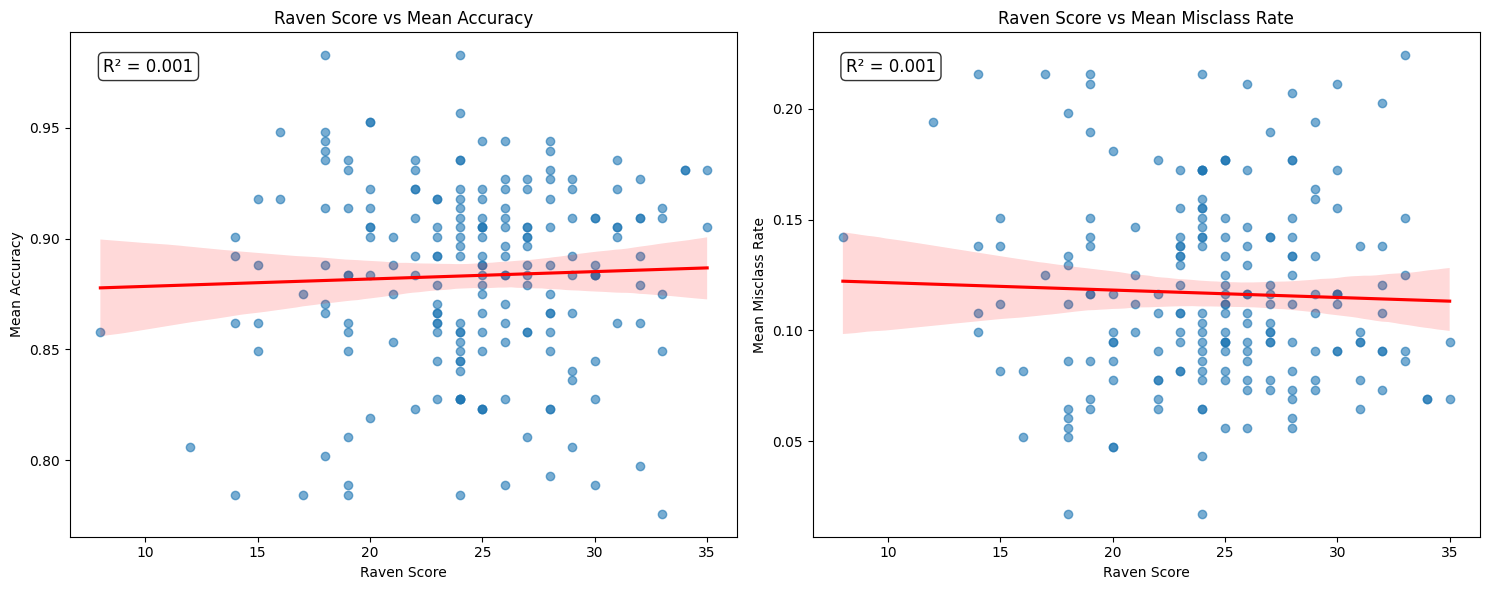

In [111]:
import numpy as np
from scipy.stats import linregress
import seaborn as sns
import matplotlib.pyplot as plt

# Create 1x2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# === PLOT 1: Raven Score vs Mean Accuracy ===
x1 = temp_data['raven_score']
y1 = temp_data['mean_accuracy']
mask1 = np.isfinite(x1) & np.isfinite(y1)
x1_clean = x1[mask1]
y1_clean = y1[mask1]

slope1, intercept1, r_value1, _, _ = linregress(x1_clean, y1_clean)
r2_1 = r_value1**2

sns.regplot(x=x1_clean, y=y1_clean, ax=ax1,
            scatter_kws={'alpha': 0.6},
            line_kws={'color': 'red'})

ax1.set_xlabel('Raven Score')
ax1.set_ylabel('Mean Accuracy')
ax1.set_title('Raven Score vs Mean Accuracy')
ax1.text(0.05, 0.95, f'R² = {r2_1:.3f}', transform=ax1.transAxes,
         fontsize=12, va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# === PLOT 2: Raven Score vs Mean Misclass Rate ===
x2 = temp_data['raven_score']
y2 = temp_data['mean_misclass_rate']
mask2 = np.isfinite(x2) & np.isfinite(y2)
x2_clean = x2[mask2]
y2_clean = y2[mask2]

slope2, intercept2, r_value2, _, _ = linregress(x2_clean, y2_clean)
r2_2 = r_value2**2

sns.regplot(x=x2_clean, y=y2_clean, ax=ax2,
            scatter_kws={'alpha': 0.6},
            line_kws={'color': 'red'})

ax2.set_xlabel('Raven Score')
ax2.set_ylabel('Mean Misclass Rate')
ax2.set_title('Raven Score vs Mean Misclass Rate')
ax2.text(0.05, 0.95, f'R² = {r2_2:.3f}', transform=ax2.transAxes,
         fontsize=12, va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


In [113]:
# Calculate pearson correlation between raven score and mean accuracy
pearson_corr = temp_data['raven_score'].corr(temp_data['mean_accuracy'])
print(f"Pearson correlation between Raven Score and Mean Accuracy: {pearson_corr}")

# Calculate pearson correlation between raven score and mean misclass rate
pearson_corr = temp_data['raven_score'].corr(temp_data['mean_misclass_rate'])
print(f"Pearson correlation between Raven Score and Mean Misclass Rate: {pearson_corr}")

Pearson correlation between Raven Score and Mean Accuracy: 0.03863280584752031
Pearson correlation between Raven Score and Mean Misclass Rate: -0.03863280584752032
